In [1]:
# 04_ltv
#
# 목적: 근사 LTV(Lifetime Value)를 계산하고, 이미 학습한 LightGBM 이탈확률과 결합해
#      "Retention Priority"(누구를 먼저 케어해야 하는가) 세그먼트를 만든다.
#
# 중요 — 이 LTV는 근사치다 (생존분석 아님):
#   - avg_monthly_revenue = 총 결제액 / 결제 횟수 (한 번의 결제 주기를 대략 한 달로 취급하는 단순화.
#     실제로는 payment_plan_days가 30일이 아닌 플랜도 있어 정확하지 않음)
#   - expected_lifetime = 1 / 이탈확률 (구독 이탈이 매달 동일 확률로 일어난다는 "상수 이탈률" 가정의
#     단순 공식. Kaplan-Meier 같은 생존분석 기법을 쓰지 않은 근사치이며, 극단적으로 낮은 이탈확률에서
#     수명이 비현실적으로 길어지는 것을 막기 위해 하한(1%)과 상한(60개월)을 둔다)
#   - ltv_approx는 참고 지표로 계산은 하되, 세그먼트 분류의 "가치" 축으로는 쓰지 않는다.
#     이유는 아래 세그먼트 계산 셀의 주석 참고 (churn_proba와 순환 종속되는 문제 발견)
#
# 세그먼트 분류: 이탈확률(risk)은 F1-최적 threshold, 가치(value)는 avg_monthly_revenue 중앙값 기준
# (두 축을 독립적으로 유지 — 자세한 이유는 세그먼트 계산 셀 참고)
#
# 입력: data/processed/model_table_final.csv, features_transactions.csv, models/lightgbm_final.txt,
#      models/best_params.json
# 출력: 시각화만

In [2]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")

sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})
QUADRANT_COLORS = {
    "고위험/고가치": "#e34948",
    "고위험/저가치": "#eda100",
    "저위험/고가치": "#1baf7a",
    "저위험/저가치": "#2a78d6",
}

CHURN_PROBA_FLOOR = 0.01
LIFETIME_CAP_MONTHS = 60

In [3]:
df = pd.read_csv(PROCESSED_DIR / "model_table_final.csv")
df["city"] = df["city"].astype("int64").astype("category")
df["registered_via"] = df["registered_via"].astype("int64").astype("category")
df["gender"] = df["gender"].astype("category")

DROP_COLS = ["msno", "snapshot", "split", "is_churn"]
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

model = lgb.Booster(model_file=str(MODELS_DIR / "lightgbm_final.txt"))
df["churn_proba"] = model.predict(df[FEATURE_COLS])

# 유저가 두 스냅샷(2월/3월)에 다 있으면 평균 이탈확률을 대표값으로 사용
user_churn_proba = df.groupby("msno")["churn_proba"].mean().rename("churn_proba")
print(f"유저 수: {len(user_churn_proba):,}, 평균 이탈확률: {user_churn_proba.mean():.4f}")

유저 수: 1,082,190, 평균 이탈확률: 0.1066


In [4]:
txn = pd.read_csv(PROCESSED_DIR / "features_transactions.csv", usecols=["msno", "total_amount_paid", "txn_count"])
txn["avg_monthly_revenue"] = txn["total_amount_paid"] / txn["txn_count"].clip(lower=1)

ltv_df = txn.merge(user_churn_proba, on="msno", how="inner")

ltv_df["churn_proba_floored"] = ltv_df["churn_proba"].clip(lower=CHURN_PROBA_FLOOR)
ltv_df["expected_lifetime_months"] = (1 / ltv_df["churn_proba_floored"]).clip(upper=LIFETIME_CAP_MONTHS)
ltv_df["ltv_approx"] = ltv_df["avg_monthly_revenue"] * ltv_df["expected_lifetime_months"]

print(f"교차검증 대상 유저: {len(ltv_df):,}명")
print(ltv_df[["avg_monthly_revenue", "expected_lifetime_months", "ltv_approx"]].describe())

교차검증 대상 유저: 1,079,663명
       avg_monthly_revenue  expected_lifetime_months    ltv_approx
count         1.079663e+06              1.079663e+06  1.079663e+06
mean          1.615301e+02              4.442949e+01  5.731800e+03
std           1.865003e+02              2.269730e+01  3.191783e+03
min           0.000000e+00              1.002091e+00  0.000000e+00
25%           9.900000e+01              2.794293e+01  3.732123e+03
50%           1.420769e+02              6.000000e+01  5.940000e+03
75%           1.490000e+02              6.000000e+01  8.414118e+03
max           2.000000e+03              6.000000e+01  5.904000e+04


In [5]:
import json

with open(MODELS_DIR / "best_params.json") as f:
    best_params = json.load(f)

# "고위험" 기준: population median 대신 모델의 F1-최적 threshold를 사용한다.
# 이유: churn_proba 분포가 심하게 치우쳐 있어(중앙값 0.012, 평균 0.107, 최대 0.998) median split을 쓰면
# 절대적으로는 위험하지 않은 유저(확률 1~2%)까지 "고위험"으로 분류되는 문제가 있었다.
# threshold(0.326)는 02단계 Optuna 튜닝에서 valid셋 F1을 최대화하도록 실제로 고른 값이라 더 의미 있는 기준선이다.
#
# "가치" 기준: ltv_approx 대신 avg_monthly_revenue(현재 월평균 매출)를 사용한다.
# 이유: ltv_approx = 매출 x (1/이탈확률)이라서 고위험 유저는 기대수명이 구조적으로 짧아지고,
# 그 결과 아무리 매출이 높아도 population 전체의 ltv_approx 중앙값을 못 넘는 문제가 실제로 발생했다
# (고위험/고가치 세그먼트가 0명으로 나옴). 위험도와 현재 가치를 서로 독립적인 축으로 봐야
# 두 축을 곱해서 만든 파생 지표(ltv_approx)로 다시 축을 나누는 순환 논리를 피할 수 있다.
RISK_THRESHOLD = best_params["threshold"]
revenue_median = ltv_df["avg_monthly_revenue"].median()

def quadrant(row):
    risk = "고위험" if row["churn_proba"] >= RISK_THRESHOLD else "저위험"
    value = "고가치" if row["avg_monthly_revenue"] >= revenue_median else "저가치"
    return f"{risk}/{value}"

ltv_df["segment"] = ltv_df.apply(quadrant, axis=1)
print(f"고위험 기준 threshold: {RISK_THRESHOLD:.4f}, 고가치 기준 월매출 중앙값: {revenue_median:.1f} NTD")
print(ltv_df["segment"].value_counts())

고위험 기준 threshold: 0.3261, 고가치 기준 월매출 중앙값: 142.1 NTD
segment
저위험/저가치    508057
저위험/고가치    446024
고위험/고가치     93912
고위험/저가치     31670
Name: count, dtype: int64


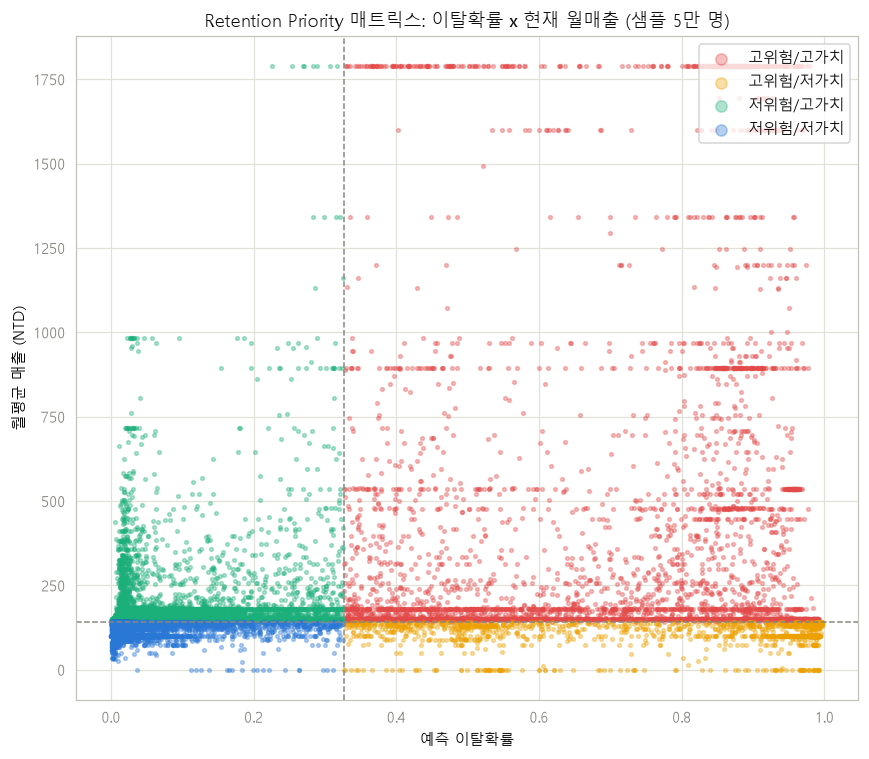

In [6]:
# 산점도가 너무 무거우니 시각화용으로만 5만 명 샘플링 (분석/집계는 전체 데이터로 이미 완료됨)
sample = ltv_df.sample(n=min(50_000, len(ltv_df)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 7))
for seg, color in QUADRANT_COLORS.items():
    sub = sample[sample["segment"] == seg]
    ax.scatter(sub["churn_proba"], sub["avg_monthly_revenue"], s=6, alpha=0.35, color=color, label=seg)

ax.axvline(RISK_THRESHOLD, color="#898781", linestyle="--", linewidth=1)
ax.axhline(revenue_median, color="#898781", linestyle="--", linewidth=1)
ax.set_xlabel("예측 이탈확률")
ax.set_ylabel("월평균 매출 (NTD)")
ax.set_title("Retention Priority 매트릭스: 이탈확률 x 현재 월매출 (샘플 5만 명)")
ax.legend(markerscale=3, loc="upper right")
plt.tight_layout()
plt.show()

In [7]:
# "고위험/고가치" 세그먼트 예시 (실제 액션은 취하지 않음, 우선순위 후보군 식별 데모)
top_priority = (
    ltv_df[ltv_df["segment"] == "고위험/고가치"]
    .sort_values("avg_monthly_revenue", ascending=False)
    .head(10)[["msno", "churn_proba", "avg_monthly_revenue", "expected_lifetime_months", "ltv_approx"]]
)
print(f"고위험/고가치 세그먼트 규모: {(ltv_df['segment'] == '고위험/고가치').sum():,}명")
top_priority

고위험/고가치 세그먼트 규모: 93,912명


,msno,churn_proba,avg_monthly_revenue,expected_lifetime_months,ltv_approx
920198,qVSCXTfk9lpZuBi0zx+Oxpno1N3p9Wi188Wqj0oDK/Q=,0.835228,2000.0,1.197278,2394.556861
928891,r0j7mP9/2qa7gprF3gYSkMyTr4lz8EzI2+7wvpPI/rY=,0.420065,2000.0,2.380585,4761.169736
725853,f0iyqdaGJ57SF8m7+YwEJhexvXnMHYToEBKOCcxv6Nw=,0.879271,2000.0,1.137306,2274.611423
627471,ZADRV3bu4863wRaWH1cjKFk2EvdAY/KBC7dIE0Hza1Y=,0.847823,2000.0,1.179492,2358.983405
260639,DRk03WVvI2MBeaVD8cFYBjzALE09fGG0PH+zCv1JPIs=,0.605241,2000.0,1.652236,3304.471159
891139,onEFyAfVkt0FxyS1Bm1GnlB8dY8oPnWmgWPIfA1ZSmU=,0.881184,2000.0,1.134837,2269.674691
181900,8mRdK5HdZ3+qJcU6g0h2jpG7XnssdhPO7QHRXHVgsAc=,0.925564,2000.0,1.080423,2160.845558
971594,tXldlo1ywBQKwILPtVmNOMbpVOg12WSctsQGr9uFTSo=,0.875169,2000.0,1.142636,2285.271970
916093,qG0FKyMmEd61CL2+zoDuEgn79MGXzvU/GRpbYmfs0lQ=,0.673423,2000.0,1.484951,2969.901732
993587,urs4unwOjlX1zE2+yDsMezeAzQwuG5mnonAgkIPWSTg=,0.880451,2000.0,1.135782,2271.563238


In [8]:
# ------------------------------------------------------------------
# 해석 시 주의할 점
# 1. LTV는 "결제횟수=개월 수" 단순화 + "1/이탈확률" 상수 이탈률 근사 공식으로 계산한 추정치다.
#    Kaplan-Meier 등 생존분석 기반 정밀 LTV가 아니며, 방향성 참고용으로만 써야 한다.
# 2. 이탈확률은 LightGBM 모델의 예측값으로, 실제 이탈 여부가 아니다 (모델 성능만큼의 오차 존재).
# 3. "고위험/고가치" 세그먼트 식별은 우선순위 후보군을 보여주는 데모이며, 실제 Retention Action을
#    수행하거나 그 효과를 측정한 것은 아니다.
# ------------------------------------------------------------------
print("LTV 및 Retention Priority 분석 완료 (위 주석의 해석 주의사항 참고)")

LTV 및 Retention Priority 분석 완료 (위 주석의 해석 주의사항 참고)
